# Title : Sms Spam Collection Classifier

## Standard ML Workflow :
* `(Data Loading → EDA → Cleaning → Preprocessing → Modeling → Evaluation) `



## 1. Install Packages :

In [ ]:
# Install required packages
!pip install pandas scikit-learn nltk xgboost matplotlib seaborn joblib

### 2. Import Libraries :

In [ ]:
# Install required libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## 3. Load the Data :

In [ ]:
# Load dataset
from google.colab import files
uploaded = files.upload()


Saving SMSSpamCollection to SMSSpamCollection


In [ ]:
import io

# Assuming 'SMSSpamCollection' is the name of the uploaded file and it's tab-separated
file_content = uploaded['SMSSpamCollection']
df = pd.read_csv(io.BytesIO(file_content), sep='\t', header=None, names=['label', 'message'])
print("Data loaded successfully!")

Data loaded successfully!


## 4. Explore the dataset :

In [ ]:
 # Check first five rows of data
 print("\nFirst Five Rows:")
 print(df.head())



First Five Rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
# Check label distribution
print("\nLabel Distribution:")
print(df['label'].value_counts())


Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
# Check shape
print("\nShape of the dataset:")
print(df.shape)


Shape of the dataset:
(5572, 2)


In [ ]:
# Check columns and datatype
print("\nColumns and Data Types:")
print(df.info())


Columns and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [ ]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
label      0
message    0
dtype: int64


In [ ]:
# Check for duplicates
print("\nNumber of Duplicates:", df.duplicated().sum())


Number of Duplicates: 403


In [ ]:
# Sumarize the data
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


## 5.  Data Cleaning :

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

In [ ]:
# Convert labels
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [ ]:
 # Text cleaning
def clean_data(df):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    def clean_text(text):
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'\@\w+|\#|[^a-zA-Z\s]', '', text)
        text = text.lower()
        tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
        return ' '.join(tokens)

    df['cleaned_text'] = df['message'].apply(clean_text)
    print("\nText cleaning completed!")
    print(f"\nCleaned text sample:\n{df['cleaned_text'].head()}")
    return df

df = clean_data(df)


Text cleaning completed!

Cleaned text sample:
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
3                  u dun say early hor u c already say
4             nah dont think go usf life around though
Name: cleaned_text, dtype: object


## 6. Feature Engineering  :

In [ ]:
def vectorize_text(df):
    tfidf = TfidfVectorizer(max_features=5000)
    X = tfidf.fit_transform(df['cleaned_text'])
    y = df['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    print("\nText vectorization completed!")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, tfidf

X_train, X_test, y_train, y_test, tfidf = vectorize_text(df)


Text vectorization completed!
Train shape: (4135, 5000), Test shape: (1034, 5000)


## 7. Model Training  :

In [ ]:
def train_models(X_train, y_train):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(),
        "Naive Bayes": MultinomialNB(),
        "XGBoost": XGBClassifier()
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        print(f"\n{name} trained successfully!")
    return models

models = train_models(X_train, y_train)



Logistic Regression trained successfully!

Random Forest trained successfully!

Naive Bayes trained successfully!

XGBoost trained successfully!


## 8. Model Evaluation :

In [ ]:
def evaluate_models(models, X_test, y_test):
    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        results[name] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': report['weighted avg']['precision'],
            'recall': report['weighted avg']['recall'],
            'f1': report['weighted avg']['f1-score']
        }

        print(f"\n{name} Performance:")
        print(classification_report(y_test, y_pred))
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

    return pd.DataFrame(results).T

results_df = evaluate_models(models, X_test, y_test)



Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       903
           1       0.98      0.61      0.75       131

    accuracy                           0.95      1034
   macro avg       0.96      0.80      0.86      1034
weighted avg       0.95      0.95      0.94      1034

Confusion Matrix:
[[901   2]
 [ 51  80]]

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.83      0.90       131

    accuracy                           0.98      1034
   macro avg       0.97      0.91      0.94      1034
weighted avg       0.98      0.98      0.98      1034

Confusion Matrix:
[[900   3]
 [ 22 109]]

Naive Bayes Performance:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       903
           1       1.00      0.76      0.87       131

    accuracy

## 9. Hyperparameter Tuning (XGBoost) :

In [ ]:
def optimize_xgboost(X_train, y_train):
    params = {
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200]
    }

    grid = GridSearchCV(XGBClassifier(), params, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    print("\nBest parameters found:")
    print(grid.best_params_)

    return grid.best_estimator_

best_model = optimize_xgboost(X_train, y_train)



Best parameters found:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


## 10. Final evaluation :


Optimized Model Performance:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.96      0.83      0.89       131

    accuracy                           0.97      1034
   macro avg       0.97      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034



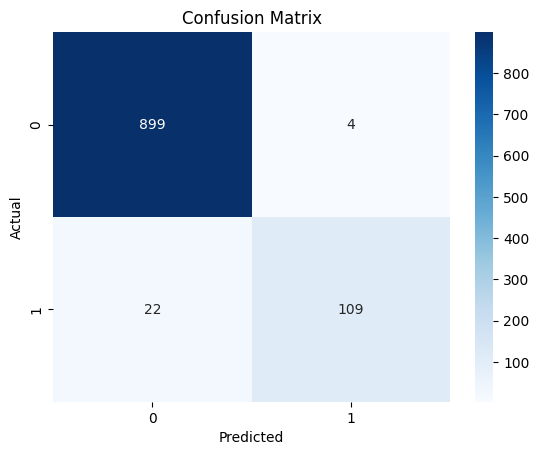

In [ ]:
def final_evaluation(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("\nOptimized Model Performance:")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

final_evaluation(best_model, X_test, y_test)


## 11. Save artifacts :

In [ ]:
def save_artifacts(model, vectorizer):
    joblib.dump(model, 'spam_classifier.pkl')
    joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
    print("\nModel and vectorizer saved successfully!")

save_artifacts(best_model, tfidf)


Model and vectorizer saved successfully!
